# Konfigurasi & Import

In [39]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report
)
import torch

SAVE_DIR   = r"C:\kuliah-sementara\SKRIPSI\lstm_models_nthuddd2"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["drowsy", "notdrowsy"]

# Load Semua Hasil JSON

In [40]:
# Baca semua file *_test_result.json dari setiap subfolder
all_results = []
for model_id in os.listdir(SAVE_DIR):
    result_path = os.path.join(SAVE_DIR, model_id, f"{model_id}_test_result.json")
    if os.path.exists(result_path):
        with open(result_path) as f:
            all_results.append(json.load(f))

df = pd.DataFrame(all_results)
print(f"Total model terbaca: {len(df)}")
#print(df[["model_id","test_acc","test_f1_macro","test_precision","test_recall","test_roc_auc"]])

Total model terbaca: 8


# Ranking Model (Terbaik → Terburuk)

In [41]:
df_ranked = df.sort_values(
    by=["test_f1_macro", "drowsy_missed"],
    ascending=[False, True]   # F1 tinggi DULU, lalu drowsy_missed rendah
).reset_index(drop=True)
df_ranked.index += 1  # Rank mulai dari 1

print("=" * 80)
print("  RANKING MODEL — TERBAIK KE TERBURUK (Kriteria: F1 Macro & Drowsy Missed)")
print("=" * 80)
print(f"{'Rank':>4} | {'Model':>20} | {'Acc':>6} | {'F1':>6} | "
      f"{'Prec':>6} | {'Recall':>6} | {'AUC':>6} | {'Missed':>6}")
print("-" * 80)
for rank, row in df_ranked.iterrows():
    print(f"  {rank:>2} | {row['model_id']:>20} | {row['test_acc']:.4f} | "
          f"{row['test_f1_macro']:.4f} | {row['test_precision']:.4f} | "
          f"{row['test_recall']:.4f} | {row['test_roc_auc']:.4f} | "
          f"{int(row['drowsy_missed']):>6}")

# Simpan ke CSV
df_ranked.to_csv(os.path.join(SAVE_DIR, "ranking_semua_model.csv"), index=True)
print("\n✓ Ranking tersimpan: ranking_semua_model.csv")

  RANKING MODEL — TERBAIK KE TERBURUK (Kriteria: F1 Macro & Drowsy Missed)
Rank |                Model |    Acc |     F1 |   Prec | Recall |    AUC | Missed
--------------------------------------------------------------------------------
   1 |         VGG19_BILSTM | 0.6728 | 0.6183 | 0.6953 | 0.6288 | 0.6875 |    356
   2 |       MOBILENET_LSTM | 0.6436 | 0.5426 | 0.7104 | 0.5839 | 0.6310 |    435
   3 |           VGG19_LSTM | 0.5814 | 0.5325 | 0.5562 | 0.5439 | 0.5771 |    380
   4 |          SWIN_BILSTM | 0.5361 | 0.5269 | 0.5269 | 0.5272 | 0.4997 |    290
   5 |            SWIN_LSTM | 0.5169 | 0.5053 | 0.5683 | 0.5550 | 0.5800 |    112
   6 |     CNN_BASIC_BILSTM | 0.5084 | 0.4860 | 0.4870 | 0.4876 | 0.5645 |    353
   7 |       CNN_BASIC_LSTM | 0.5138 | 0.4776 | 0.4822 | 0.4843 | 0.5627 |    385
   8 |     MOBILENET_BILSTM | 0.6083 | 0.4425 | 0.7644 | 0.5354 | 0.6592 |    507

✓ Ranking tersimpan: ranking_semua_model.csv


Kenapa Ranking Pakai F1 Macro, Bukan Accuracy?
Karena test set kamu imbalanced (42.1% drowsy vs 57.9% notdrowsy). Jika pakai accuracy, model yang selalu prediksi "notdrowsy" bisa dapat skor 57.9% tanpa belajar apapun. F1 Macro memaksa model harus benar di kedua kelas secara seimbang, dan ini penting karena False Negative (drowsy → diprediksi aman) adalah kesalahan paling berbahaya di sistem ini.

# Bar Chart Perbandingan F1 Semua Model

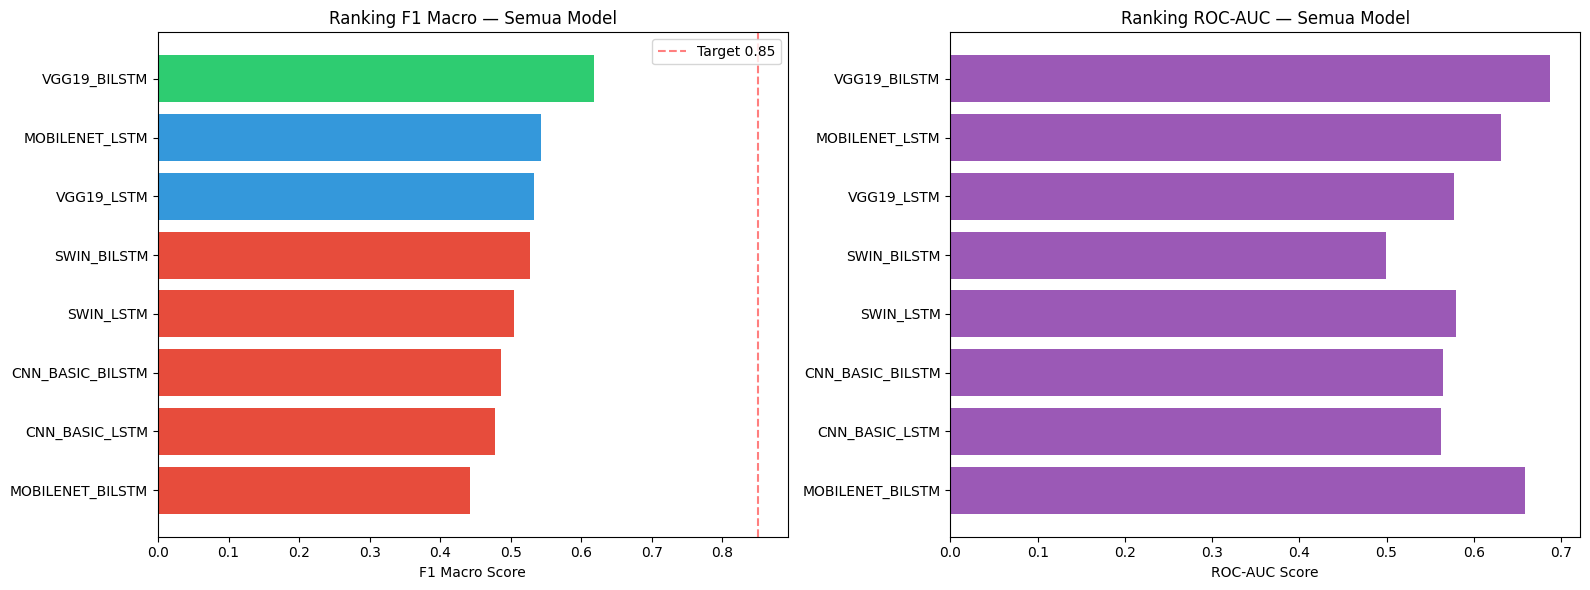

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── F1 Macro ──
colors = ["#2ecc71" if i == 0 else "#3498db" if i < 3 else "#e74c3c"
          for i in range(len(df_ranked))]
axes[0].barh(df_ranked["model_id"][::-1], df_ranked["test_f1_macro"][::-1], color=colors[::-1])
axes[0].set_xlabel("F1 Macro Score")
axes[0].set_title("Ranking F1 Macro — Semua Model")
axes[0].axvline(x=0.85, color="red", linestyle="--", alpha=0.5, label="Target 0.85")
axes[0].legend()

# ── ROC AUC ──
axes[1].barh(df_ranked["model_id"][::-1], df_ranked["test_roc_auc"][::-1], color="#9b59b6")
axes[1].set_xlabel("ROC-AUC Score")
axes[1].set_title("Ranking ROC-AUC — Semua Model")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plot_ranking_model.png"), dpi=150)
plt.show()

# Confusion Matrix Grid (8 Model Sekaligus)

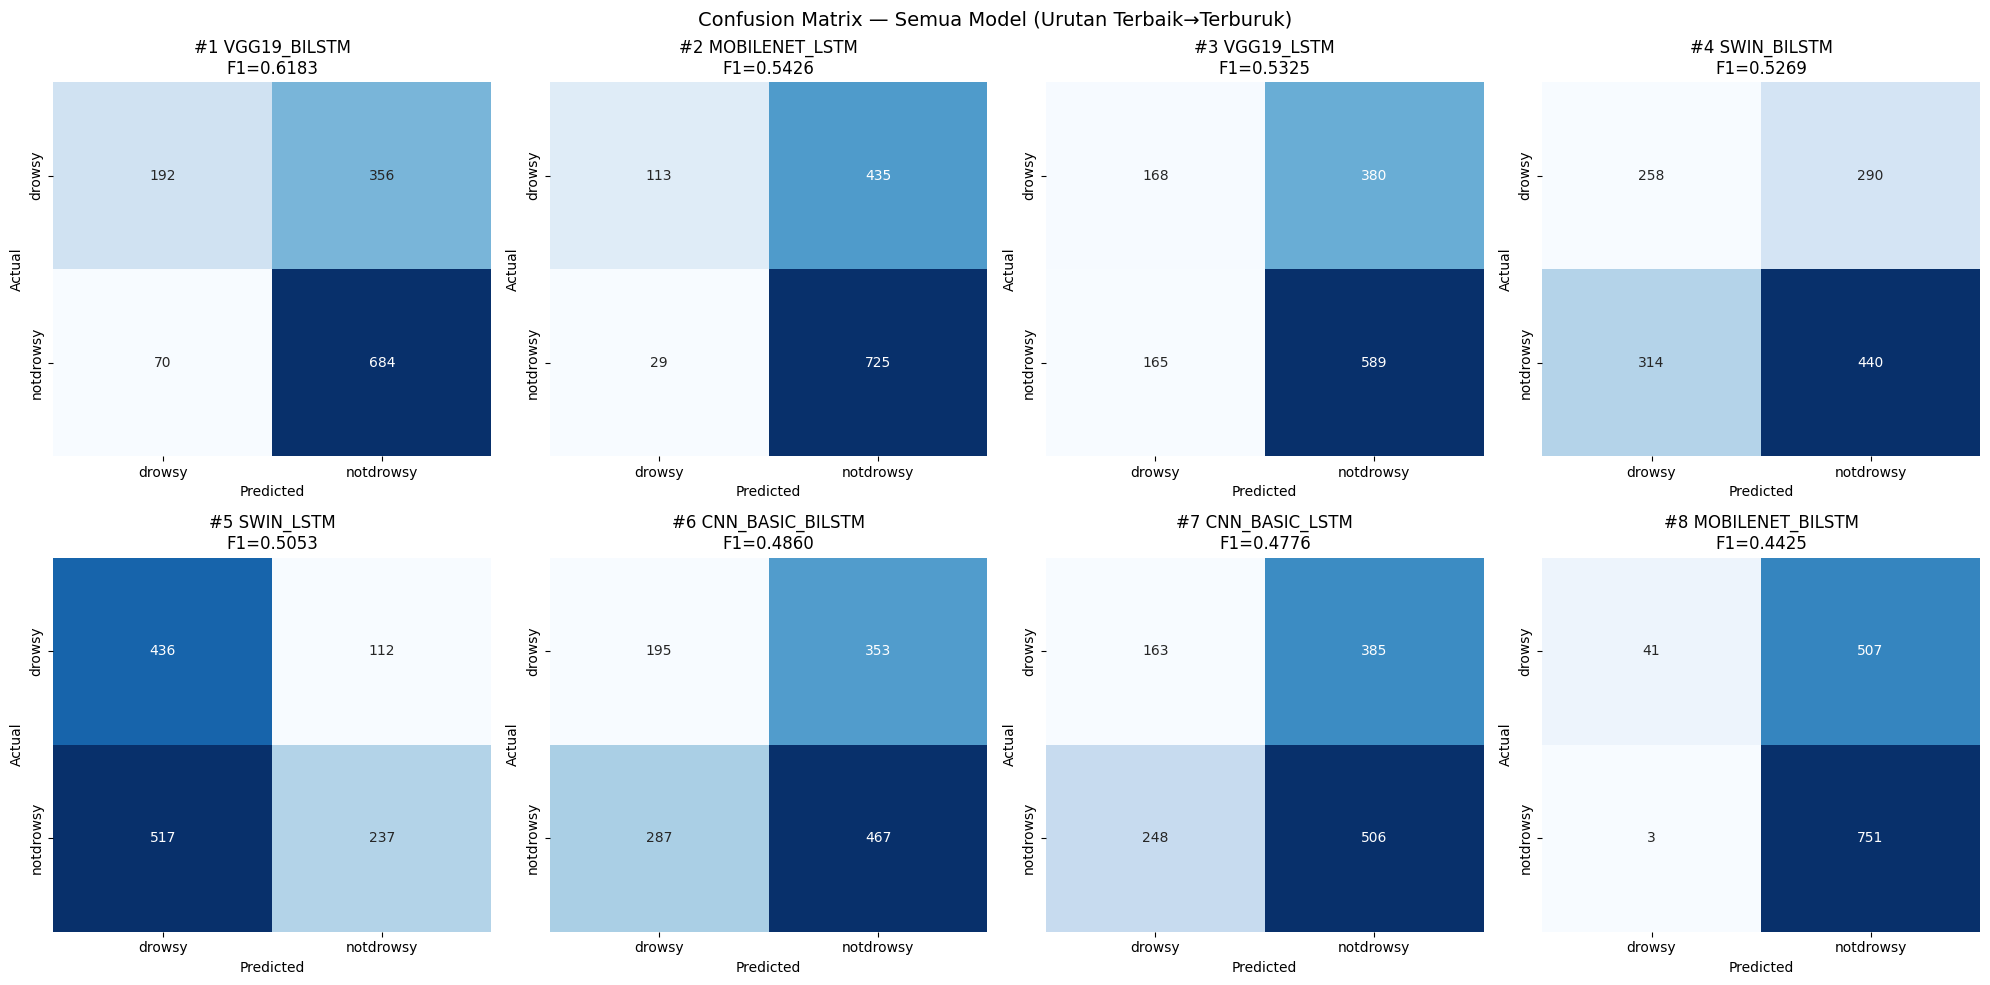

In [43]:
# Load ulang model terbaik dan re-run predict di test set
# untuk tampilkan confusion matrix semua model dalam 1 figure
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, row in df_ranked.iterrows():
    cm = np.array(row["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[i-1], cbar=False)
    axes[i-1].set_title(f"#{i} {row['model_id']}\nF1={row['test_f1_macro']:.4f}")
    axes[i-1].set_xlabel("Predicted")
    axes[i-1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Semua Model (Urutan Terbaik→Terburuk)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plot_cm_all_models.png"), dpi=150)
plt.show()

# Training History Plot (Model Terbaik)

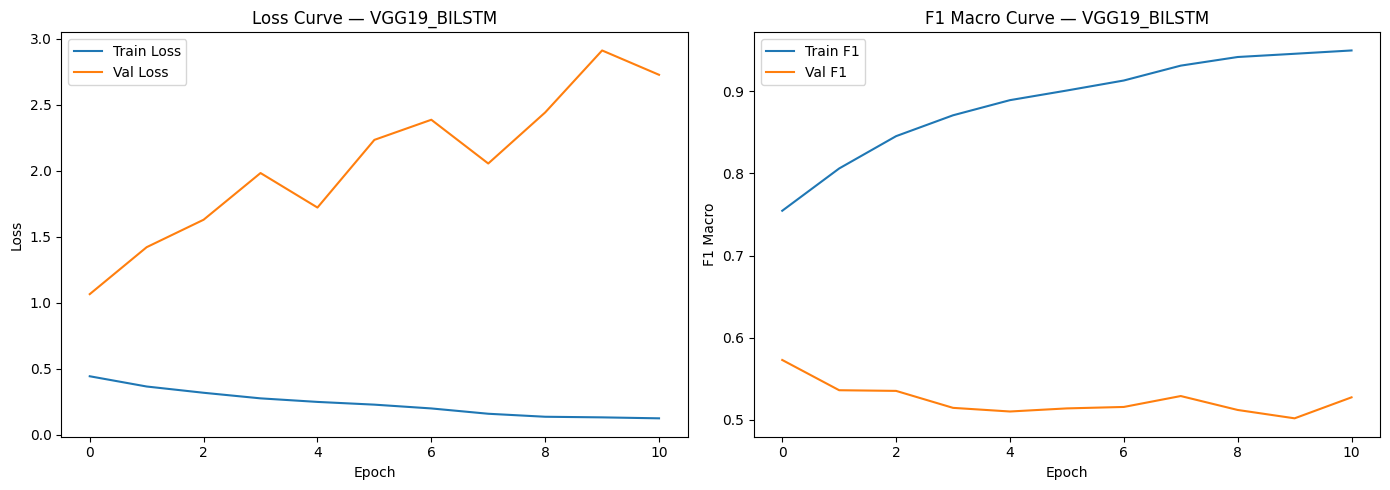

In [44]:
# Tampilkan kurva loss dan f1 dari model #1 (terbaik)
best_model_id = df_ranked.iloc[0]["model_id"]
hist_path = os.path.join(SAVE_DIR, best_model_id, f"{best_model_id}_history.json")

with open(hist_path) as f:
    hist = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(hist["train_loss"], label="Train Loss")
axes[0].plot(hist["val_loss"],   label="Val Loss")
axes[0].set_title(f"Loss Curve — {best_model_id}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

# F1 curve
axes[1].plot(hist["train_f1"], label="Train F1")
axes[1].plot(hist["val_f1"],   label="Val F1")
axes[1].set_title(f"F1 Macro Curve — {best_model_id}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 Macro")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"plot_history_{best_model_id}.png"), dpi=150)
plt.show()

# Kesimpulan Teks Otomatis

In [45]:
best  = df_ranked.iloc[0]
worst = df_ranked.iloc[-1]
print("=" * 60)
print("  KESIMPULAN EVALUASI NOTEBOOK 10")
print("=" * 60)
print(f"\n  Model TERBAIK  : {best['model_id']}")
print(f"    F1 Macro     : {best['test_f1_macro']:.4f}")
print(f"    Accuracy     : {best['test_acc']:.4f}")
print(f"    ROC-AUC      : {best['test_roc_auc']:.4f}")
print(f"    Drowsy Missed: {int(best['drowsy_missed'])} (drowsy diprediksi aman, Fatal!)")
print(f"\n  Model TERBURUK : {worst['model_id']}")
print(f"    F1 Macro     : {worst['test_f1_macro']:.4f}")
print(f"\n  Selisih F1 Best vs Worst : "
      f"{best['test_f1_macro'] - worst['test_f1_macro']:.4f}")
print(f"\n  Model yang akan dibawa ke Notebook 11 (Deployment):")
print(f"  → {best['model_id']} ✓")

  KESIMPULAN EVALUASI NOTEBOOK 10

  Model TERBAIK  : VGG19_BILSTM
    F1 Macro     : 0.6183
    Accuracy     : 0.6728
    ROC-AUC      : 0.6875
    Drowsy Missed: 356 (drowsy diprediksi aman, Fatal!)

  Model TERBURUK : MOBILENET_BILSTM
    F1 Macro     : 0.4425

  Selisih F1 Best vs Worst : 0.1758

  Model yang akan dibawa ke Notebook 11 (Deployment):
  → VGG19_BILSTM ✓
